In [1]:
import sklearn
import pandas as pd
import numpy as np
from scipy.stats import wilcoxon
import matplotlib.pyplot as plt
import seaborn as sns

from statannotations.Annotator import Annotator

In [3]:
import numpy as np

np.load('0_1_concept_attention_weights.npy')[0].shape

(20,)

In [2]:
# Load files
bin_file = "data/fold_test_bin_stageagecancerrna.csv"
cat_file = "data/fold_test_cat_stageagecancerrna.csv"

df_bin = pd.read_csv(bin_file)
df_cat = pd.read_csv(cat_file)

# Subset lambda=1
df_bin = df_bin[df_bin["lambda"] == 1]
df_cat = df_cat[df_cat["lambda"] == 1]

# --- Parse concepts ---
# Bin: average 4 (Stage), 3 (Age), 10 (Cancer)
def split_bin_concepts(row):
    vals = [float(x) for x in row.strip("[]").split(",")]
    stage = np.mean(vals[:4])
    age = np.mean(vals[4:7])
    cancer = np.mean(vals[7:17])
    rna = np.mean(vals[17:20])
    return stage, age, cancer, rna

bin_concepts = df_bin["concepts"].apply(split_bin_concepts)
df_bin[["stage_f1","age_f1","cancer_f1", "rna_f1"]] = pd.DataFrame(bin_concepts.tolist(), index=df_bin.index)

# Cat: parse 3 values directly
def split_cat_concepts(row):
    vals = [float(x) for x in row.strip("[]").split(",")]
    return vals

cat_concepts = df_cat["concepts"].apply(split_cat_concepts)
df_cat[["stage_f1","age_f1","cancer_f1","rna_f1"]] = pd.DataFrame(cat_concepts.tolist(), index=df_cat.index)

# --- Average across repeats within folds ---
def avg_within_folds(df, model_type):
    grouped = df.groupby("fold").agg({
        "task_f1s":"mean",
        "stage_f1":"mean",
        "age_f1":"mean",
        "cancer_f1":"mean",
        "rna_f1":"mean"
    }).reset_index()
    grouped["model"] = model_type
    return grouped

In [3]:
bin_avg = avg_within_folds(df_bin, "Bin")
cat_avg = avg_within_folds(df_cat, "Cat")

In [10]:
# Combine
df_avg = pd.concat([bin_avg, cat_avg])

# Reshape for plotting
df_melt = df_avg.melt(id_vars=["fold","model"],
                      value_vars=["task_f1s","stage_f1","age_f1","cancer_f1","rna_f1"],
                      var_name="metric", value_name="f1")

## --- Stats ---
#results = []
#for metric in ["task_f1s","stage_f1","age_f1","cancer_f1"]:
#    bin_vals = bin_avg[metric].values
#    cat_vals = cat_avg[metric].values
#    p = wilcoxon(cat_vals, bin_vals).pvalue
#    results.append({"metric":metric, "bin_mean":bin_vals.mean(), "cat_mean":cat_vals.mean(), "p_value":p})


pairs = [(("Task (Survival)","Bin"),("Task (Survival)","Cat")),
         (("Stage","Bin"),("Stage","Cat")),
         (("Age","Bin"),("Age","Cat")),
         (("Cancer","Bin"),("Cancer","Cat")),
         (("RNA_bio","Bin"), ("RNA_bio","Cat"))]

#stats_df = pd.DataFrame(results)

metric_labels = {
    "task_f1s": "Task (Survival)",
    "stage_f1": "Stage",
    "age_f1": "Age",
    "cancer_f1": "Cancer",
    "rna_f1": "RNA_bio"
}
df_melt["metric_label"] = df_melt["metric"].map(metric_labels)
#stats_df["metric_label"] = stats_df["metric"].map(metric_labels)

In [11]:
df_melt

,fold,model,metric,f1,metric_label
0,0.0,Bin,task_f1s,0.747370,Task (Survival)
1,1.0,Bin,task_f1s,0.728790,Task (Survival)
2,2.0,Bin,task_f1s,0.747597,Task (Survival)
3,3.0,Bin,task_f1s,0.741903,Task (Survival)
4,4.0,Bin,task_f1s,0.710994,Task (Survival)
...,...,...,...,...,...
75,3.0,Cat,rna_f1,0.646465,RNA_bio
76,4.0,Cat,rna_f1,0.655276,RNA_bio
77,5.0,Cat,rna_f1,0.630303,RNA_bio
78,6.0,Cat,rna_f1,0.623350,RNA_bio


/var/folders/wj/bwk4b7356cn68vctc2ddsfhh0000gr/T/ipykernel_49389/3661530603.py:8: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:w'` for the same effect.

  sns.stripplot(data=df_melt, x="metric_label", y="f1", hue="model",


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Stage_Bin vs. Stage_Cat: Wilcoxon test (paired samples), P_val:7.812e-03 Stat=0.000e+00
Task (Survival)_Bin vs. Task (Survival)_Cat: Wilcoxon test (paired samples), P_val:9.453e-01 Stat=1.700e+01
Age_Bin vs. Age_Cat: Wilcoxon test (paired samples), P_val:7.812e-03 Stat=0.000e+00
Cancer_Bin vs. Cancer_Cat: Wilcoxon test (paired samples), P_val:7.812e-03 Stat=0.000e+00
RNA_bio_Bin vs. RNA_bio_Cat: Wilcoxon test (paired samples), P_val:1.562e-02 Stat=1.000e+00


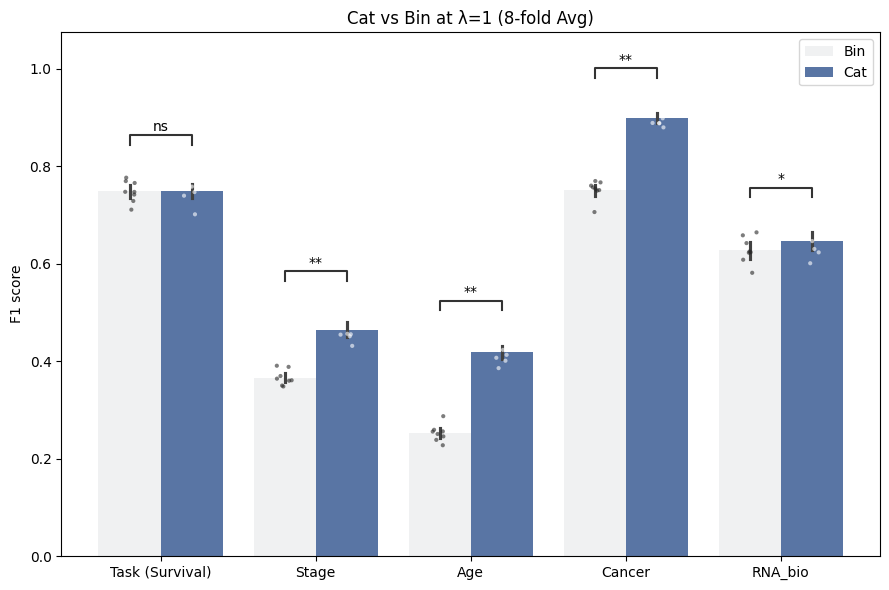

In [13]:
# --- Barplot ---
plt.figure(figsize=(9,6))

pal = sns.light_palette("#4c72b0", n_colors=2) 
ax = sns.barplot(data=df_melt, x="metric_label", y="f1", hue="model",
            palette=pal, linewidth=2)

sns.stripplot(data=df_melt, x="metric_label", y="f1", hue="model",
                dodge=True, color="w", alpha=0.6, size=3, ax=ax, legend=False)

annotator = Annotator(ax, pairs, data=df_melt, x="metric_label", y="f1", hue="model")
annotator.configure(test='Wilcoxon', text_format='star', loc='inside')
annotator.apply_and_annotate()

plt.title("Cat vs Bin at λ=1 (8-fold Avg)")
plt.ylabel("F1 score")
plt.xlabel("")
plt.legend(title="")
plt.tight_layout()
plt.savefig('RNA_plot.png')
plt.show()

      metric   p_value
0   task_f1s  0.312500
1   stage_f1  0.007812
2     age_f1  0.007812
3  cancer_f1  0.007812
4    rna_mse  0.546875


/var/folders/wj/bwk4b7356cn68vctc2ddsfhh0000gr/T/ipykernel_14109/923549201.py:99: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:w'` for the same effect.

  sns.stripplot(data=df_melt[df_melt["metric"]!="rna_mse"],
/var/folders/wj/bwk4b7356cn68vctc2ddsfhh0000gr/T/ipykernel_14109/923549201.py:109: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:k'` for the same effect.

  sns.stripplot(data=df_melt[df_melt["metric"]=="rna_mse"],


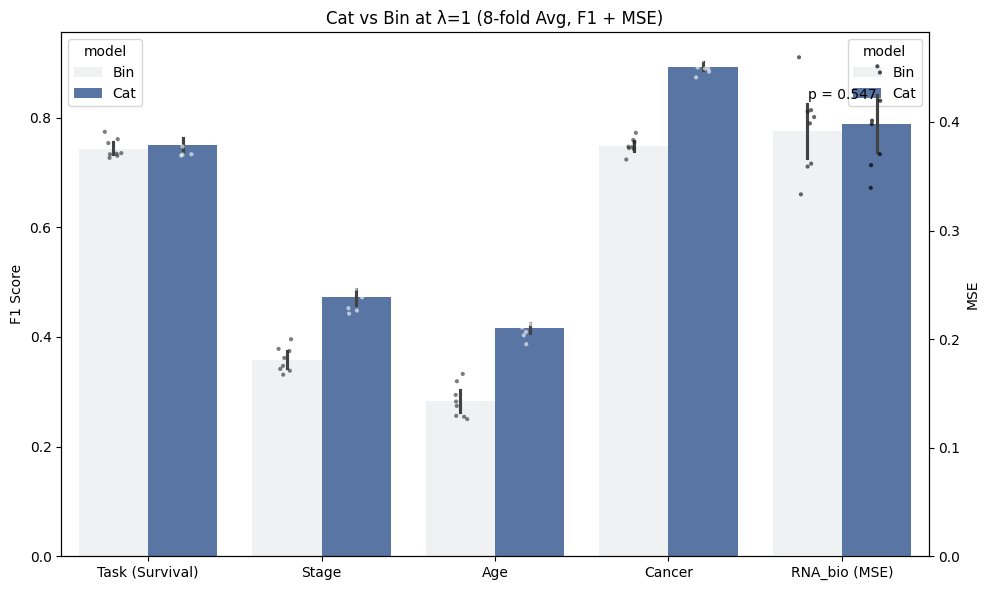

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statannotations.Annotator import Annotator
from scipy.stats import wilcoxon

# Load files
bin_file = "data/fold_test_bin_stageagecancer_rnacontinuous.csv"
cat_file = "data/fold_test_cat_stageagecancer_rnacontinuous.csv"

df_bin = pd.read_csv(bin_file)
df_cat = pd.read_csv(cat_file)

# Subset lambda=1
df_bin = df_bin[df_bin["lambda"] == 1]
df_cat = df_cat[df_cat["lambda"] == 1]

# --- Parse concepts for Bin ---
def split_bin_concepts(row):
    vals = [float(x) for x in row.strip("[]").split(",")]
    stage = np.mean(vals[:4])
    age = np.mean(vals[4:7])
    cancer = np.mean(vals[7:17])
    return stage, age, cancer

bin_concepts = df_bin["concepts"].apply(split_bin_concepts)
df_bin[["stage_f1","age_f1","cancer_f1"]] = pd.DataFrame(bin_concepts.tolist(), index=df_bin.index)

# RNA mse for Bin
import re

def extract_last_float(s):
    # Find all numbers in the string
    nums = re.findall(r"[-+]?\d*\.\d+|\d+", s)
    if len(nums) > 0:
        return float(nums[-1])  # take the last one
    else:
        return np.nan

df_bin["rna_mse"] = df_bin["concept_mses"].apply(extract_last_float)



# --- Parse concepts for Cat ---
def split_cat_concepts(row):
    vals = [float(x) for x in row.strip("[]").split(",")]
    return vals

cat_concepts = df_cat["concepts"].apply(split_cat_concepts)
df_cat[["stage_f1","age_f1","cancer_f1"]] = pd.DataFrame(cat_concepts.tolist(), index=df_cat.index)
df_cat["rna_mse"] = df_cat["concept_mses"].apply(extract_last_float)

# --- Average across repeats within folds ---
def avg_within_folds(df, model_type):
    grouped = df.groupby("fold").agg({
        "task_f1s":"mean",
        "stage_f1":"mean",
        "age_f1":"mean",
        "cancer_f1":"mean",
        "rna_mse":"mean"
    }).reset_index()
    grouped["model"] = model_type
    return grouped

bin_avg = avg_within_folds(df_bin, "Bin")
cat_avg = avg_within_folds(df_cat, "Cat")

# Combine
df_avg = pd.concat([bin_avg, cat_avg])

# --- Melt ---
df_melt = df_avg.melt(id_vars=["fold","model"],
                      value_vars=["task_f1s","stage_f1","age_f1","cancer_f1","rna_mse"],
                      var_name="metric", value_name="score")

metric_labels = {
    "task_f1s": "Task (Survival)",
    "stage_f1": "Stage",
    "age_f1": "Age",
    "cancer_f1": "Cancer",
    "rna_mse": "RNA_bio (MSE)"
}
df_melt["metric_label"] = df_melt["metric"].map(metric_labels)

pairs = [(("Task (Survival)","Bin"),("Task (Survival)","Cat")),
         (("Stage","Bin"),("Stage","Cat")),
         (("Age","Bin"),("Age","Cat")),
         (("Cancer","Bin"),("Cancer","Cat")),
         (("RNA_bio (MSE)","Bin"), ("RNA_bio (MSE)","Cat"))]


# --- Plot ---
plt.figure(figsize=(10,6))
ax = sns.barplot(data=df_melt[df_melt["metric"]!="rna_mse"], 
                 x="metric_label", y="score", hue="model",
                 palette=sns.light_palette("#4c72b0", n_colors=2), linewidth=2)

sns.stripplot(data=df_melt[df_melt["metric"]!="rna_mse"],
              x="metric_label", y="score", hue="model",
              dodge=True, color="w", alpha=0.6, size=3, ax=ax, legend=False)

# Secondary axis for RNA MSE
ax2 = ax.twinx()
sns.barplot(data=df_melt[df_melt["metric"]=="rna_mse"],
            x="metric_label", y="score", hue="model",
            palette=sns.light_palette("#4c72b0", n_colors=2), linewidth=2, ax=ax2)

sns.stripplot(data=df_melt[df_melt["metric"]=="rna_mse"],
              x="metric_label", y="score", hue="model",
              dodge=True, color="k", alpha=0.7, size=3, ax=ax2, legend=False)

from scipy.stats import wilcoxon

# --- Run stats ---
results = []
for metric in ["task_f1s","stage_f1","age_f1","cancer_f1"]:
    bin_vals = bin_avg[metric].values
    cat_vals = cat_avg[metric].values
    p = wilcoxon(cat_vals, bin_vals).pvalue
    results.append({"metric":metric, "p_value":p})

# RNA_bio (MSE) separately
bin_mse = bin_avg["rna_mse"].values
cat_mse = cat_avg["rna_mse"].values
p_mse = wilcoxon(cat_mse, bin_mse).pvalue
results.append({"metric":"rna_mse", "p_value":p_mse})

stats_df = pd.DataFrame(results)
print(stats_df)

# Suppose ax2 is the right y-axis (RNA MSE)
ax2.text(
    x=4,  # index where RNA MSE is plotted
    y=max(bin_mse.mean(), cat_mse.mean()) + 0.02,
    s=f"p = {p_mse:.3f}",
    ha='center', va='bottom', fontsize=10, color="black"
)


# Labels
ax.set_ylabel("F1 Score")
ax2.set_ylabel("MSE")
plt.title("Cat vs Bin at λ=1 (8-fold Avg, F1 + MSE)")
ax.set_xlabel("")

plt.tight_layout()
plt.show()


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Stage_Bin vs. Stage_Cat: Wilcoxon test (paired samples), P_val:7.812e-03 Stat=0.000e+00
Task (Survival)_Bin vs. Task (Survival)_Cat: Wilcoxon test (paired samples), P_val:3.125e-01 Stat=1.000e+01
Age_Bin vs. Age_Cat: Wilcoxon test (paired samples), P_val:7.812e-03 Stat=0.000e+00
Cancer_Bin vs. Cancer_Cat: Wilcoxon test (paired samples), P_val:7.812e-03 Stat=0.000e+00
RNA_bio (MSE)_Bin vs. RNA_bio (MSE)_Cat: Wilcoxon test (paired samples), P_val:5.469e-01 Stat=1.300e+01


/var/folders/wj/bwk4b7356cn68vctc2ddsfhh0000gr/T/ipykernel_14109/3902486516.py:89: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:w'` for the same effect.

  sns.stripplot(data=df_melt, x="metric_label", y="value", hue="model",


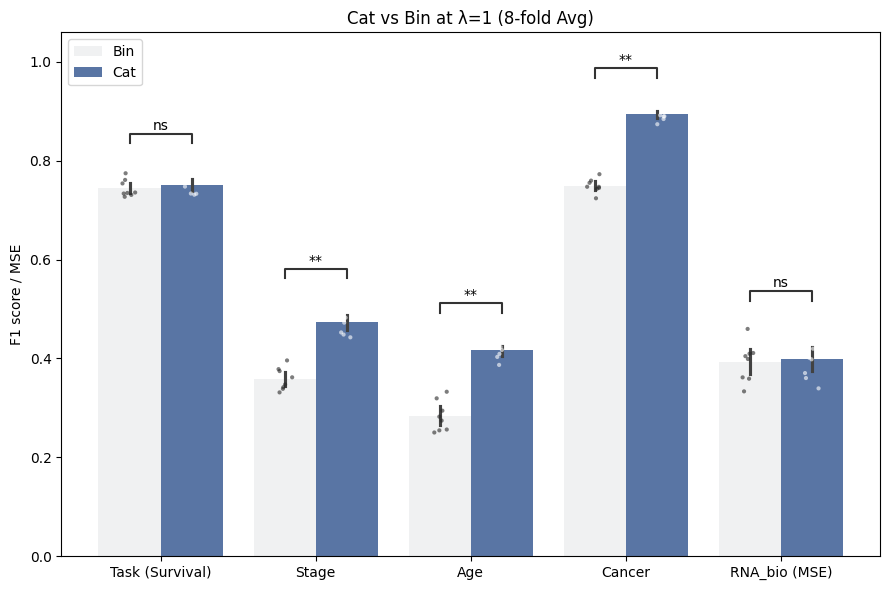

In [18]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon
from statannotations.Annotator import Annotator

# --- Load Data ---
bin_file = "data/fold_test_bin_stageagecancer_rnacontinuous.csv"
cat_file = "data/fold_test_cat_stageagecancer_rnacontinuous.csv"

df_bin = pd.read_csv(bin_file)
df_cat = pd.read_csv(cat_file)

# Subset lambda=1
df_bin = df_bin[df_bin["lambda"] == 1]
df_cat = df_cat[df_cat["lambda"] == 1]

# --- Parse concepts for Bin ---
def split_bin_concepts(row):
    vals = [float(x) for x in row.strip("[]").split(",")]
    stage = np.mean(vals[:4])
    age = np.mean(vals[4:7])
    cancer = np.mean(vals[7:17])
    return stage, age, cancer

bin_concepts = df_bin["concepts"].apply(split_bin_concepts)
df_bin[["stage_f1","age_f1","cancer_f1"]] = pd.DataFrame(bin_concepts.tolist(), index=df_bin.index)

# RNA MSE: last non-None entry
def extract_mse(row):
    vals = [v.strip() for v in row.strip("[]").split(",")]
    vals = [v for v in vals if v != "None"]
    return float(vals[-1]) if vals else np.nan

df_bin["rna_mse"] = df_bin["concept_mses"].apply(extract_mse)

# --- Parse concepts for Cat ---
def split_cat_concepts(row):
    vals = [float(x) for x in row.strip("[]").split(",")]
    return vals

cat_concepts = df_cat["concepts"].apply(split_cat_concepts)
df_cat[["stage_f1","age_f1","cancer_f1"]] = pd.DataFrame(cat_concepts.tolist(), index=df_cat.index)

df_cat["rna_mse"] = df_cat["concept_mses"].apply(extract_mse)

# --- Average within folds ---
def avg_within_folds(df, model_type):
    grouped = df.groupby("fold").agg({
        "task_f1s":"mean",
        "stage_f1":"mean",
        "age_f1":"mean",
        "cancer_f1":"mean",
        "rna_mse":"mean"
    }).reset_index()
    grouped["model"] = model_type
    return grouped

bin_avg = avg_within_folds(df_bin, "Bin")
cat_avg = avg_within_folds(df_cat, "Cat")

df_avg = pd.concat([bin_avg, cat_avg])

# --- Reshape into long format ---
df_melt = df_avg.melt(
    id_vars=["fold","model"],
    value_vars=["task_f1s","stage_f1","age_f1","cancer_f1","rna_mse"],
    var_name="metric", value_name="value"
)

# Label metrics
metric_labels = {
    "task_f1s": "Task (Survival)",
    "stage_f1": "Stage",
    "age_f1": "Age",
    "cancer_f1": "Cancer",
    "rna_mse": "RNA_bio (MSE)"
}
df_melt["metric_label"] = df_melt["metric"].map(metric_labels)

# --- Plot ---
plt.figure(figsize=(9,6))
pal = sns.light_palette("#4c72b0", n_colors=2)

ax = sns.barplot(data=df_melt, x="metric_label", y="value", hue="model",
                 palette=pal, linewidth=2)

sns.stripplot(data=df_melt, x="metric_label", y="value", hue="model",
              dodge=True, color="w", alpha=0.6, size=3, ax=ax, legend=False)

# --- Stats ---
pairs = [
    (("Task (Survival)","Bin"),("Task (Survival)","Cat")),
    (("Stage","Bin"),("Stage","Cat")),
    (("Age","Bin"),("Age","Cat")),
    (("Cancer","Bin"),("Cancer","Cat")),
    (("RNA_bio (MSE)","Bin"),("RNA_bio (MSE)","Cat"))
]

annotator = Annotator(ax, pairs, data=df_melt, x="metric_label", y="value", hue="model")
annotator.configure(test='Wilcoxon', text_format='star', loc='inside')
annotator.apply_and_annotate()

ax.set_title("Cat vs Bin at λ=1 (8-fold Avg)")
ax.set_ylabel("F1 score / MSE")
ax.set_xlabel("")
ax.legend(title="", loc="upper left")

plt.tight_layout()
plt.savefig('f1_rna_mse.png')
plt.show()
